---

# DATA VISUALIZATION

---

In this section we'll cover basic **data visualization** in Pandas, and use the plot method to create & customize line charts, bar charts, pie charts, scatterplots, and histograms

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sales_df = pd.DataFrame({'date': ['2013-03-01', '2013-03-02', '2013-03-03', '2013-03-04','2013-03-05'],
                         'beverage':[809, 950, 1000, 750, 595],
                         'alcohol':[75, 117, 0, 50, 41],
                         'grocery':[3105, 4044, 4186, 3525, 2815],
                         'prepared_foods':[81, 75, 80, 90, 60]})
sales_df

,date,beverage,alcohol,grocery,prepared_foods
0,2013-03-01,809,75,3105,81
1,2013-03-02,950,117,4044,75
2,2013-03-03,1000,0,4186,80
3,2013-03-04,750,50,3525,90
4,2013-03-05,595,41,2815,60


In [3]:
sales_df['date'] = pd.to_datetime(sales_df['date'])
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            5 non-null      datetime64[ns]
 1   beverage        5 non-null      int64         
 2   alcohol         5 non-null      int64         
 3   grocery         5 non-null      int64         
 4   prepared_foods  5 non-null      int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 332.0 bytes


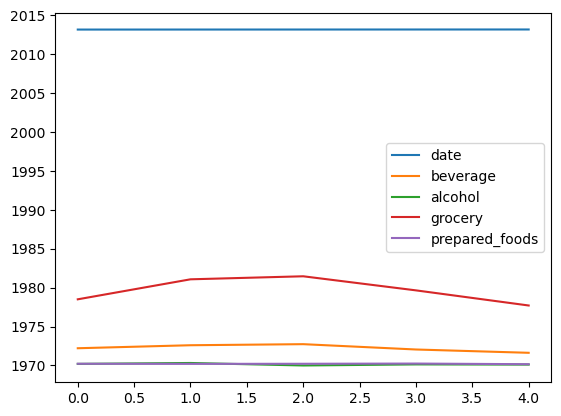

In [4]:
sales_df.plot();

<Axes: xlabel='date'>

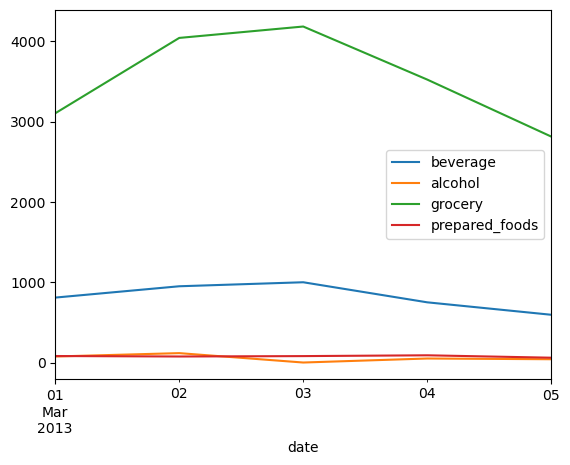

In [5]:
sales_df.set_index('date').plot()

<Axes: xlabel='date'>

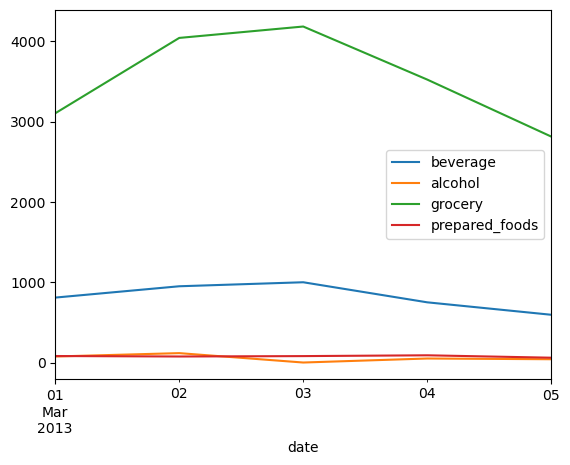

In [6]:
sales_df.plot(x='date')

<Axes: xlabel='date'>

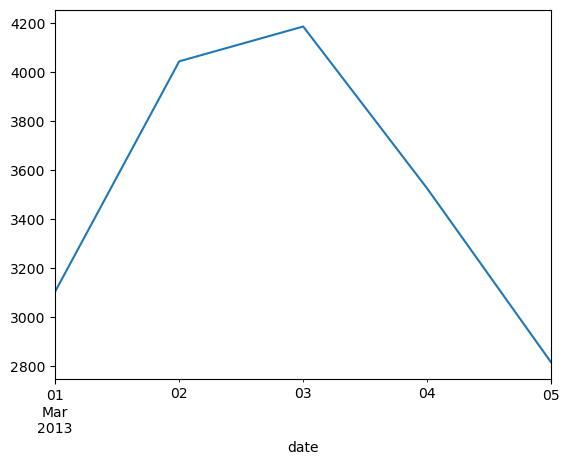

In [7]:
sales_df.set_index('date').loc[:, 'grocery'].plot()

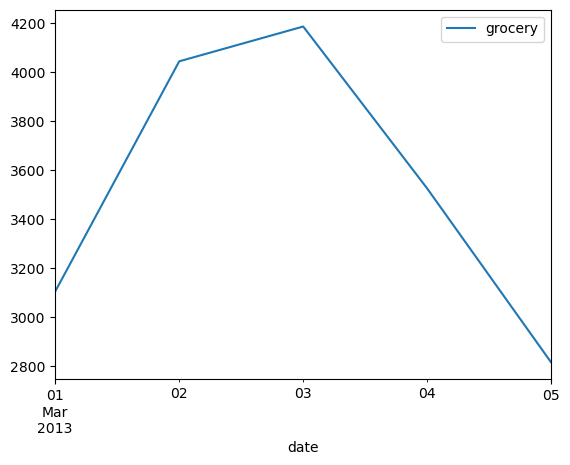

In [8]:
sales_df.plot(x='date', y='grocery');

---

## LABORATORY

In [9]:
transactions = pd.read_csv('Data/transactions.csv', parse_dates=['date'])
transactions.head(3)

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358


In [10]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB


In [11]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


<Axes: >

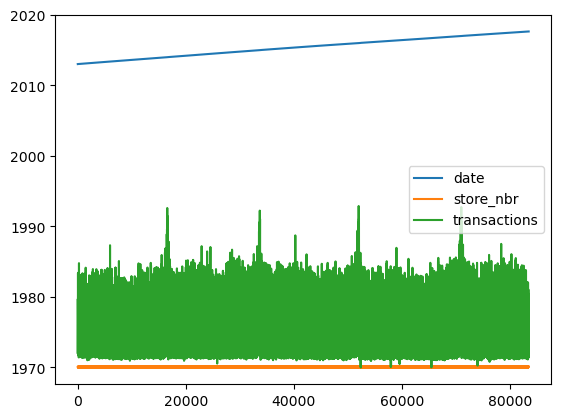

In [12]:
transactions.plot()

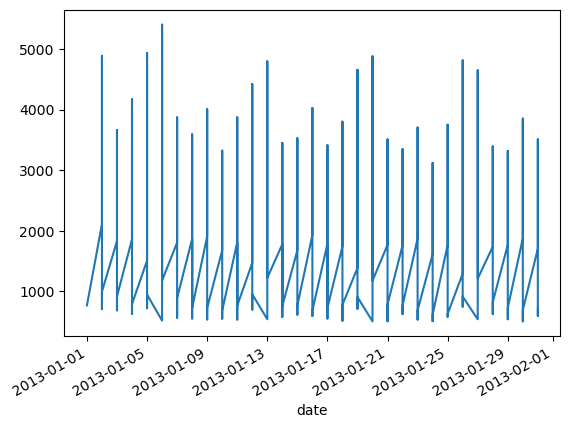

In [13]:
transactions.set_index('date').loc['2013-01', 'transactions'].plot();

---

The plot is irregular and it has no aparent pattern, because there are many data points for each day. Since there are many records for each day of each store. Let's see it...

In [14]:
transactions[(transactions['date'].dt.month == 1) & (transactions['date'].dt.year == 2013)]

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922
...,...,...,...
1376,2013-01-31,48,2432
1377,2013-01-31,49,1573
1378,2013-01-31,50,2153
1379,2013-01-31,51,1524


<Axes: xlabel='date'>

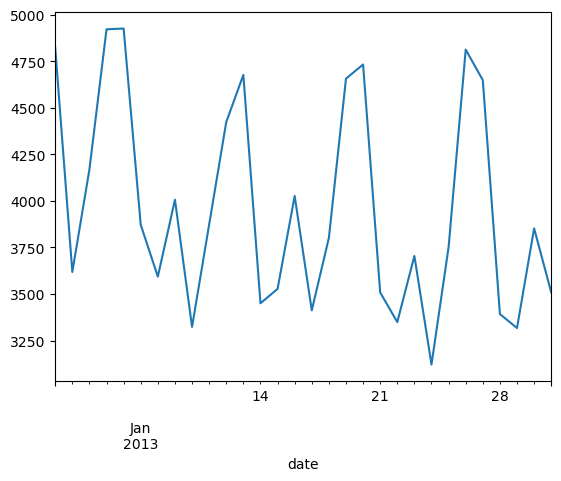

In [15]:
transactions.query("store_nbr == 44").set_index('date').loc['2013-01', 'transactions'].plot()

In [16]:
# another way to obtain the same result is...
store_44 = transactions[transactions.store_nbr == 44][['date', 'transactions']].reset_index()
store_44.head()

,index,date,transactions
0,38,2013-01-02,4821
1,84,2013-01-03,3618
2,130,2013-01-04,4169
3,176,2013-01-05,4921
4,222,2013-01-06,4925


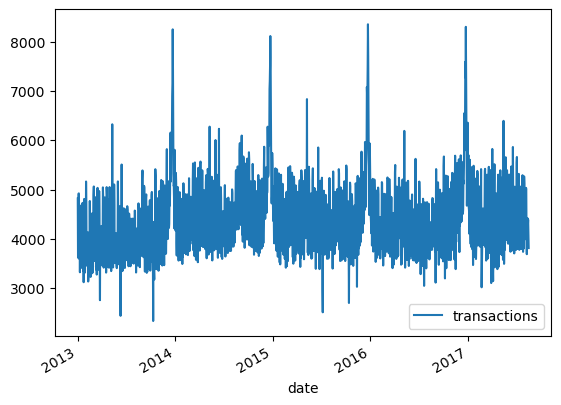

In [17]:
store_44.plot(x='date', y='transactions');

<Axes: xlabel='date'>

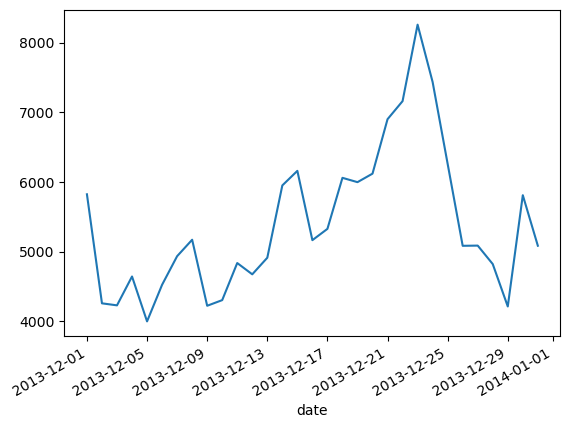

In [18]:
# let's see only a frame of 30 days of December 2013
store_44.query("date.dt.year == 2013 and date.dt.month == 12").set_index('date').loc[:, 'transactions'].plot()

<Axes: xlabel='date'>

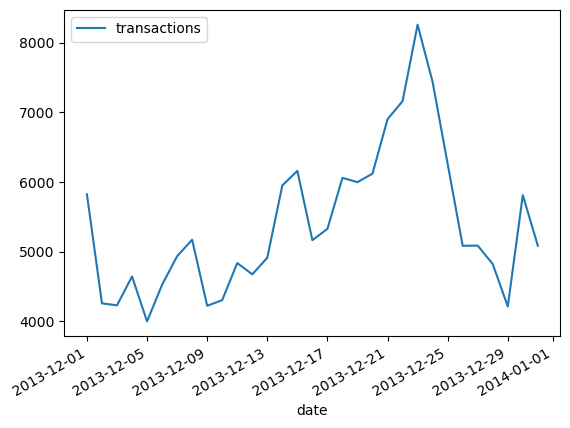

In [19]:
# Same plot but now using Method 2
store_44.query("date.dt.year == 2013 and date.dt.month == 12").plot(x='date', y='transactions')

---

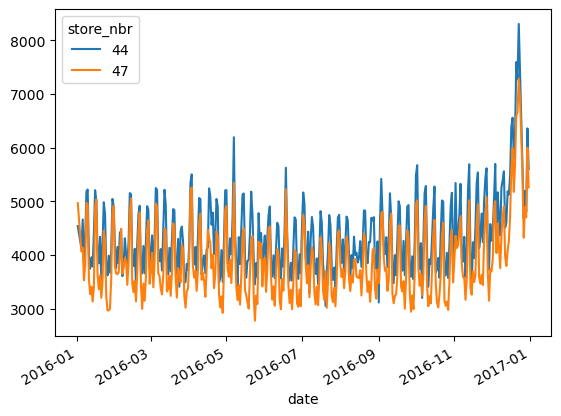

In [20]:
(transactions
    .query("store_nbr in [44, 47] and date.dt.year == 2016")
    .pivot_table(index='date', columns='store_nbr', values='transactions')
    .plot()
);

---

## ASSIGNMENT: PLOT METHOD

In [21]:
oil = pd.read_csv('Data/oil.csv', parse_dates=['date'])
oil.columns = ['date', 'price']
oil

,date,price
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
...,...,...
1213,2017-08-25,47.65
1214,2017-08-28,46.40
1215,2017-08-29,46.46
1216,2017-08-30,45.96


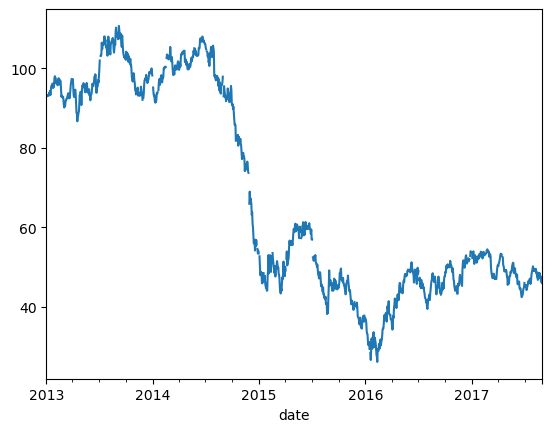

In [22]:
oil.set_index('date').loc[:, 'price'].plot();

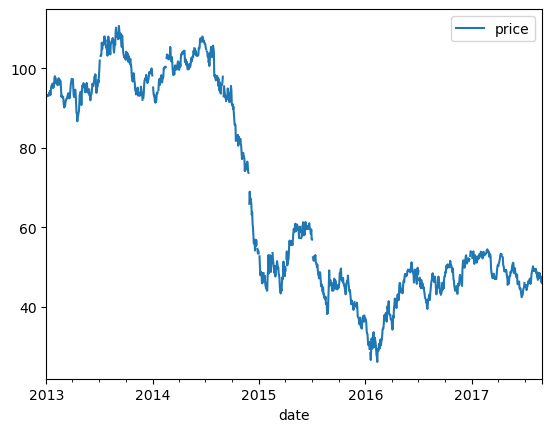

In [25]:
oil.plot(x='date', y='price');

<Axes: xlabel='date'>

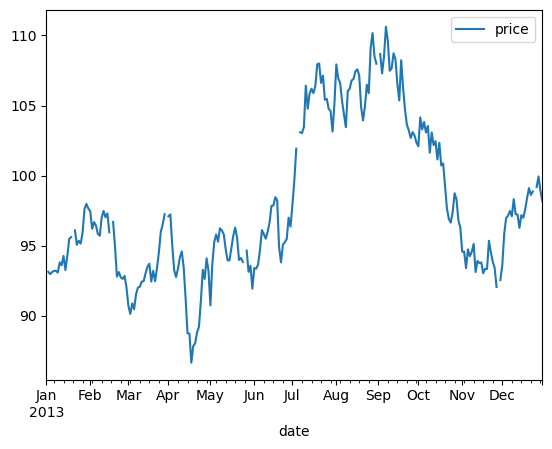

In [26]:
# But if we would want to filter by date we should use the 1st method...

oil.set_index('date').loc['2013'].plot()

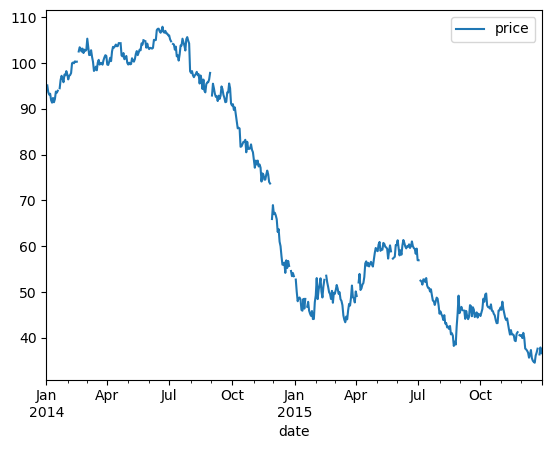

In [29]:
# Or a plot with the data of 2 years
oil.set_index('date').loc['2014':'2015'].plot();